In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pymaid
import seaborn as sns
import math

GABA_THRESHOLD = 40
MATCH_THRESHOLD = 350
ALPHA = 0.05
base_path = os.path.expanduser("~/Downloads/")

In [2]:
seymour_rm = pymaid.CatmaidInstance(
    server="https://neurophyla.mrc-lmb.cam.ac.uk/catmaid/drosophila/l1/seymour/",
    api_token='a94b27c8f28f9af9be3a781ada26f99731e105db',
    http_user='imakkar',
    http_password='daunting-cynical-hurdles',
)

gaba_rm = pymaid.CatmaidInstance(
    server="https://neurophyla.mrc-lmb.cam.ac.uk/catmaid/fibsem/",
    api_token='ffa463360b6032c9528a020209097ef0609b6243',
    http_user='imakkar',
    http_password='daunting-cynical-hurdles',
    project_id=7,
)

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)
INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


In [3]:
# GABA skid → (Seymour skid, label)
training_map = {
    302092:   (3690921,  'Lower Looping PN R'),
    305507:   (3002410,  'Upper Looping PN R'),
    21895315: (6554358,  'DPMpl1/2 double desc. R'),
}

In [4]:
def fetch_cable_um(skid, rm):
    """Fetch cable length for a single skeleton in micrometres."""
    try:
        n = pymaid.get_neuron(skid, remote_instance=rm)
        return n.cable_length / 1000   # nm → μm
    except Exception as e:
        print(f"  Failed to fetch skid {skid}: {e}")
        return np.nan

In [5]:
training_records = []
for gaba_skid, (sey_skid, label) in training_map.items():
    training_records.append({
        'label':           label,
        'skid_gaba':       gaba_skid,
        'skid_seymour':    sey_skid,
        'cable_gaba_um':   fetch_cable_um(gaba_skid,  gaba_rm),
        'cable_seymour_um': fetch_cable_um(sey_skid,  seymour_rm),
        'group':           'Training',
    })

df_training = pd.DataFrame(training_records)
print(df_training[['label', 'cable_gaba_um', 'cable_seymour_um']])

                     label  cable_gaba_um  cable_seymour_um
0       Lower Looping PN R     163.437500        365.905060
1       Upper Looping PN R     139.586777        334.128387
2  DPMpl1/2 double desc. R     153.671600        359.393738


In [11]:
# Confirmed L/R DAMd1 pairs with known Seymour skids
# Source: annotations in CATMAID GABA volume
damd1_pairs = [
    {'mbon': 'MBON-d3', 'skid_gaba_L': '44394901', 'skid_gaba_R': '20480',
     'skid_seymour_L': '9109799', 'skid_seymour_R': '9074101'},
    {'mbon': 'MBON-e2', 'skid_gaba_L': '44395977', 'skid_gaba_R': '20474',
     'skid_seymour_L': '8922644', 'skid_seymour_R': '8297018'},
    {'mbon': 'MBON-i1', 'skid_gaba_L': '13883',    'skid_gaba_R': '20496',
     'skid_seymour_L': '7802210', 'skid_seymour_R': '16797672'},
    {'mbon': 'MBON-j1', 'skid_gaba_L': '44396000', 'skid_gaba_R': '20490',
     'skid_seymour_L': '15421363', 'skid_seymour_R': '3299214'},
    {'mbon': 'MBON-k1', 'skid_gaba_L': '44396235', 'skid_gaba_R': '20486',
     'skid_seymour_L': '16846805', 'skid_seymour_R': '18028397'},
]

# Two unidentified DAMd1 R neurons (13889, 20506) are excluded
# as they have no confirmed MBON identity or Seymour counterpart

damd1_records = []
for pair in damd1_pairs:
    for side, gaba_col, sey_col in [('L', 'skid_gaba_L', 'skid_seymour_L'),
                                     ('R', 'skid_gaba_R', 'skid_seymour_R')]:
        damd1_records.append({
            'label':            f"{pair['mbon']} {side}",
            'skid_gaba':        pair[gaba_col],
            'skid_seymour':     pair[sey_col],
            'cable_gaba_um':    fetch_cable_um(pair[gaba_col],  gaba_rm),
            'cable_seymour_um': fetch_cable_um(pair[sey_col],   seymour_rm),
            'group':            'DAMd1',
        })

df_damd1 = pd.DataFrame(damd1_records)
print(df_damd1[['label', 'cable_gaba_um', 'cable_seymour_um']])

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (

       label  cable_gaba_um  cable_seymour_um
0  MBON-d3 L     143.960495        546.671509
1  MBON-d3 R     124.121956        529.142761
2  MBON-e2 L     106.472748        370.153564
3  MBON-e2 R     150.352768        388.976166
4  MBON-i1 L     154.995483        522.760864
5  MBON-i1 R     157.669189        501.040802
6  MBON-j1 L     159.030548        550.061279
7  MBON-j1 R     168.246597        533.590820
8  MBON-k1 L     114.933517        655.281250
9  MBON-k1 R     128.946762        560.279602


In [12]:
all_neurons = pd.concat([df_training, df_damd1], ignore_index=True)

print(f"\nTotal neurons : {len(all_neurons)}")
print(f"Missing Seymour cable : {all_neurons['cable_seymour_um'].isna().sum()}")
print(all_neurons[['group', 'label', 'cable_gaba_um', 'cable_seymour_um']])


Total neurons : 13
Missing Seymour cable : 0
       group                    label  cable_gaba_um  cable_seymour_um
0   Training       Lower Looping PN R     163.437500        365.905060
1   Training       Upper Looping PN R     139.586777        334.128387
2   Training  DPMpl1/2 double desc. R     153.671600        359.393738
3      DAMd1                MBON-d3 L     143.960495        546.671509
4      DAMd1                MBON-d3 R     124.121956        529.142761
5      DAMd1                MBON-e2 L     106.472748        370.153564
6      DAMd1                MBON-e2 R     150.352768        388.976166
7      DAMd1                MBON-i1 L     154.995483        522.760864
8      DAMd1                MBON-i1 R     157.669189        501.040802
9      DAMd1                MBON-j1 L     159.030548        550.061279
10     DAMd1                MBON-j1 R     168.246597        533.590820
11     DAMd1                MBON-k1 L     114.933517        655.281250
12     DAMd1                MBO

In [13]:
groups = ['Training', 'DAMd1', 'All neurons']

subsets = {
    'Training':    all_neurons[all_neurons['group'] == 'Training'],
    'DAMd1':       all_neurons[all_neurons['group'] == 'DAMd1'],
    'All neurons': all_neurons,
}

stats = {}
for grp in groups:
    sub = subsets[grp].dropna(subset=['cable_gaba_um', 'cable_seymour_um'])
    for vol, col in [('gaba', 'cable_gaba_um'), ('seymour', 'cable_seymour_um')]:
        stats.setdefault(grp, {})[vol] = {
            'n':    len(sub),
            'mean': sub[col].mean(),
            'sd':   sub[col].std(ddof=1),
            'med':  sub[col].median(),
            'min':  sub[col].min(),
            'max':  sub[col].max(),
        }

x         = np.arange(len(groups))
bar_width  = 0.35
gaba_means    = [stats[g]['gaba']['mean']    for g in groups]
gaba_sds      = [stats[g]['gaba']['sd']      for g in groups]
seymour_means = [stats[g]['seymour']['mean'] for g in groups]
seymour_sds   = [stats[g]['seymour']['sd']   for g in groups]

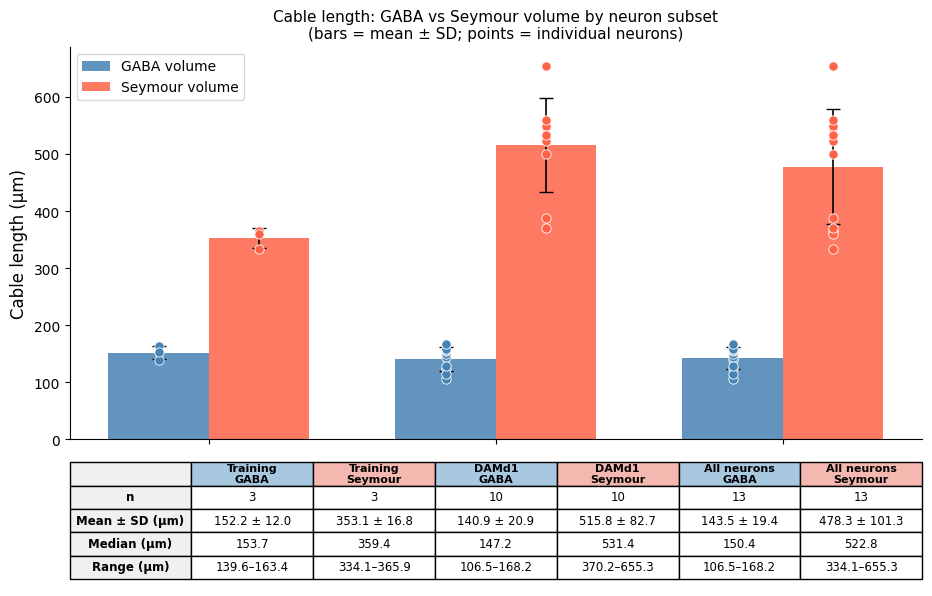

In [14]:
fig = plt.figure(figsize=(11, 7))
gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.06)
ax       = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])
ax_table.axis('off')

# Bars
ax.bar(x - bar_width/2, gaba_means, bar_width,
       yerr=gaba_sds, capsize=5,
       color='steelblue', alpha=0.85, label='GABA volume',
       error_kw={'linewidth': 1.2})
ax.bar(x + bar_width/2, seymour_means, bar_width,
       yerr=seymour_sds, capsize=5,
       color='tomato', alpha=0.85, label='Seymour volume',
       error_kw={'linewidth': 1.2})

# Individual data points
for i, grp in enumerate(groups):
    sub = subsets[grp].dropna(subset=['cable_gaba_um', 'cable_seymour_um'])
    ax.scatter(np.full(len(sub), x[i] - bar_width/2), sub.cable_gaba_um,
               color='steelblue', edgecolors='white', s=45, zorder=5, lw=0.6)
    ax.scatter(np.full(len(sub), x[i] + bar_width/2), sub.cable_seymour_um,
               color='tomato',    edgecolors='white', s=45, zorder=5, lw=0.6)

ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_ylabel('Cable length (μm)', fontsize=12)
ax.set_title(
    'Cable length: GABA vs Seymour volume by neuron subset\n'
    '(bars = mean ± SD; points = individual neurons)',
    fontsize=11
)
ax.legend(fontsize=10)
ax.set_ylim(0, None)
sns.despine(ax=ax)

# ── Summary table ──────────────────────────────────────────────────────────
col_labels = [
    '', 
    'Training\nGABA',    'Training\nSeymour',
    'DAMd1\nGABA',       'DAMd1\nSeymour',
    'All neurons\nGABA', 'All neurons\nSeymour',
]
row_labels = ['n', 'Mean ± SD (μm)', 'Median (μm)', 'Range (μm)']

def fmt(grp, vol):
    s = stats[grp][vol]
    return [
        str(s['n']),
        f"{s['mean']:.1f} ± {s['sd']:.1f}",
        f"{s['med']:.1f}",
        f"{s['min']:.1f}–{s['max']:.1f}",
    ]

cols = {
    'Training_gaba':       fmt('Training',    'gaba'),
    'Training_seymour':    fmt('Training',    'seymour'),
    'DAMd1_gaba':          fmt('DAMd1',       'gaba'),
    'DAMd1_seymour':       fmt('DAMd1',       'seymour'),
    'All_gaba':            fmt('All neurons', 'gaba'),
    'All_seymour':         fmt('All neurons', 'seymour'),
}

table_data = []
for i, rl in enumerate(row_labels):
    table_data.append([
        rl,
        cols['Training_gaba'][i],    cols['Training_seymour'][i],
        cols['DAMd1_gaba'][i],       cols['DAMd1_seymour'][i],
        cols['All_gaba'][i],         cols['All_seymour'][i],
    ])

tbl = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)

for col_idx, label in enumerate(col_labels):
    cell = tbl[0, col_idx]
    if 'GABA'    in label: cell.set_facecolor('#a8c8e0')
    elif 'Seymour' in label: cell.set_facecolor('#f5b8b0')
    else:                    cell.set_facecolor('#f0f0f0')
    cell.set_text_props(fontweight='bold', fontsize=8)

for row_idx in range(1, len(row_labels) + 1):
    tbl[row_idx, 0].set_text_props(fontweight='bold')
    tbl[row_idx, 0].set_facecolor('#f0f0f0')

